In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataSet = pd.read_csv("USA Housing Dataset.csv")

In [4]:
dataSet = dataSet[dataSet["price"] <= 1185251]

In [5]:
dataSet.shape

(3933, 18)

In [6]:
dataSet = dataSet[dataSet["price"] > 0]

In [7]:
dataSet = dataSet[dataSet["price"] > 9000]

In [9]:
dataSet = dataSet.drop(columns = ["country", "statezip", "street"])

In [10]:
dataSet = dataSet.drop(columns = ["date", "sqft_living", "waterfront", "view", "sqft_above", "sqft_basement", "yr_built", "yr_renovated"])

<Axes: >

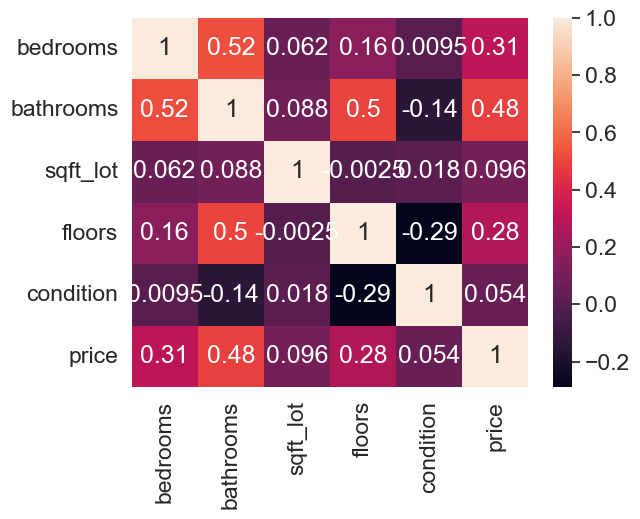

In [12]:
import seaborn as sns

numeric_cols = ["bedrooms", "bathrooms", "sqft_lot", "floors", "condition", "price"]
cm = np.corrcoef(dataSet[numeric_cols].values.T)
sns.set(font_scale = 1.5)
sns.heatmap(cm, annot = True, yticklabels = numeric_cols, xticklabels = numeric_cols)

In [13]:
dataSet = pd.get_dummies(dataSet, columns = ['city'], drop_first = True)

In [16]:
X_cols = list(set(dataSet.columns) - set(['price']))
y_cols = ['price']

X = dataSet[X_cols].values
y = dataSet[y_cols].values

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [18]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [21]:
#Lasso model
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [22]:
y_pred = lasso.predict(X_test) 

In [23]:
import sklearn.metrics as metrics

mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

In [24]:
print("MSE: ", mse)
print("R2: ", r2)

MSE:  21880476355.75161
R2:  0.5435519509387935
